# Notebook 09: Molecular Docking Validation

## AI-Based Identification of Novel Drug Targets for Depression

### Overview

This notebook validates the high-confidence novel drug-target predictions obtained from the machine learning stage using molecular docking.

The predicted drug-protein pairs are matched with their available AlphaFold protein structures, and binding pockets are identified using fpocket. The selected ligands and protein receptors are then prepared for molecular docking using the required structural formats.

AutoDock Vina is used to dock each selected drug into the predicted binding pocket of its corresponding protein. The resulting docking affinity scores are analysed to assess the predicted binding of the selected drug-target pairs.

The selected protein structures and docking poses are also visually inspected using PyMOL. This provides an additional structural view of the predicted interactions and supports the interpretation of the docking results.

### Dataset

The inputs used in this notebook are the high-confidence novel drug-target predictions generated from the machine learning stage, together with the corresponding protein structures and drug information.

The protein structures are obtained from the AlphaFold structure data prepared during the protein analysis stage, while the drug information is obtained from the processed drug-target interaction data.

### Project Workflow

This notebook represents the molecular docking validation stage of the project:

1. Select high-confidence novel drug-target predictions.
2. Match predicted protein targets with their AlphaFold structures.
3. Identify and rank binding pockets using fpocket.
4. Prepare ligand structures for docking.
5. Prepare protein receptors as rigid PDBQT files.
6. Verify the docking input files.
7. Calculate the centres of the selected binding pockets.
8. Prepare the final docking input table.
9. Perform molecular docking using AutoDock Vina.
10. Check the quality of the docking affinity results.
11. Separate valid negative-affinity and anomalous docking results.
12. Visually inspect representative docking poses using PyMOL.
13. Visualise and analyse the docking scores.
14. Save the final docking results for later interpretation and thesis reporting.

### Objectives

The objectives of this notebook are:

1. Validate selected novel drug-target predictions using molecular docking.
2. Identify suitable binding pockets in the predicted protein structures.
3. Prepare ligands and protein receptors for AutoDock Vina.
4. Evaluate the predicted binding affinity of the selected drug-target pairs.
5. Identify and separately report anomalous docking results.
6. Visually inspect representative protein-ligand docking poses using PyMOL.
7. Save the validated docking results for further analysis and thesis reporting.

In [3]:
# 1. Import Required Libraries

import os
import glob
import shutil
import subprocess
import warnings
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Python libraries imported successfully.")

Python libraries imported successfully.


In [4]:
# 2. Set Up Project Directories

from google.colab import drive

drive.mount("/content/drive")

PROJECT_ROOT = "/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI"

RAW_DATA_PATH = os.path.join(PROJECT_ROOT, "data", "raw")
PROCESSED_DATA_PATH = os.path.join(PROJECT_ROOT, "data", "processed")
STRUCTURES_PATH = os.path.join(RAW_DATA_PATH, "structures")
RESULTS_PATH = os.path.join(PROJECT_ROOT, "results")
FIGURE_PATH = os.path.join(PROJECT_ROOT, "figures")
DOCKING_PATH = os.path.join(PROJECT_ROOT, "docking")
DOCKING_RESULTS_PATH = os.path.join(DOCKING_PATH, "results")

PROTEIN_PATH = os.path.join(DOCKING_PATH, "proteins")
CLEANED_PROTEIN_PATH = os.path.join(DOCKING_RESULTS_PATH, "cleaned_proteins")
LIGAND_PATH = os.path.join(DOCKING_RESULTS_PATH, "ligands")
LIGAND_PDBQT_PATH = os.path.join(DOCKING_RESULTS_PATH, "ligands_pdbqt")
RECEPTOR_PDBQT_PATH = os.path.join(DOCKING_RESULTS_PATH, "receptors_pdbqt")
POCKET_PATH = os.path.join(DOCKING_RESULTS_PATH, "pockets")
DOCKED_POSE_PATH = os.path.join(DOCKING_RESULTS_PATH, "docked_poses")

for directory in [
    RESULTS_PATH,
    FIGURE_PATH,
    DOCKING_PATH,
    DOCKING_RESULTS_PATH,
    PROTEIN_PATH,
    CLEANED_PROTEIN_PATH,
    LIGAND_PATH,
    LIGAND_PDBQT_PATH,
    RECEPTOR_PDBQT_PATH,
    POCKET_PATH,
    DOCKED_POSE_PATH
]:
    os.makedirs(directory, exist_ok=True)

print("Project directories configured successfully.")
print("Project root:", PROJECT_ROOT)

Mounted at /content/drive
Project directories configured successfully.
Project root: /content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI


In [5]:
# 3. Check Required Input Files

ranked_predictions_file = os.path.join(
    RESULTS_PATH,
    "gnn_ranked_candidate_predictions.csv"
)

interaction_file = os.path.join(
    RAW_DATA_PATH,
    "drug_target_interactions.csv"
)

print("Checking required input files...")

required_files = {
    "Ranked predictions": ranked_predictions_file,
    "Drug-target interactions": interaction_file
}

for name, path in required_files.items():
    print(f"{name}: {'found' if os.path.exists(path) else 'missing'}")
    print(" ", path)

structure_files = sorted(
    glob.glob(os.path.join(STRUCTURES_PATH, "*.pdb"))
)

print("\nAlphaFold structures found:", len(structure_files))

Checking required input files...
Ranked predictions: found
  /content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/results/gnn_ranked_candidate_predictions.csv
Drug-target interactions: found
  /content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/data/raw/drug_target_interactions.csv

AlphaFold structures found: 174


In [6]:
# 4. Load Ranked Predictions

ranked_predictions = pd.read_csv(ranked_predictions_file)

print("Ranked prediction data loaded successfully.")
print("Number of prediction records:", len(ranked_predictions))
print("\nPrediction columns:")
print(ranked_predictions.columns.tolist())

display(ranked_predictions.head())

Ranked prediction data loaded successfully.
Number of prediction records: 3590

Prediction columns:
['uniprot_id', 'drug_chembl_id', 'true_label', 'predicted_label', 'prediction_probability']


,uniprot_id,drug_chembl_id,true_label,predicted_label,prediction_probability
0,P31645,CHEMBL106939,1,1,1.0
1,P31645,CHEMBL174088,1,1,1.0
2,P31645,CHEMBL432394,1,1,1.0
3,P43681,CHEMBL2179551,1,1,1.0
4,P43681,CHEMBL2179547,1,1,1.0


In [7]:
# 5. Select High-Confidence Novel Drug-Target Candidates

required_prediction_columns = [
    "uniprot_id",
    "drug_chembl_id",
    "prediction_probability"
]

missing_columns = [
    col for col in required_prediction_columns
    if col not in ranked_predictions.columns
]

if missing_columns:
    raise KeyError(
        f"Required prediction columns are missing: {missing_columns}"
    )

novel_candidates = ranked_predictions.copy()

# The modelling notebook provides true_label and predicted_label.
# These are used to keep only predicted positives that were not known
# as positive interactions in the labelled dataset.
if {"true_label", "predicted_label"}.issubset(novel_candidates.columns):

    novel_candidates = novel_candidates[
        (novel_candidates["true_label"] == 0) &
        (novel_candidates["predicted_label"] == 1)
    ].copy()

else:
    raise KeyError(
        "The prediction file does not contain true_label and predicted_label. "
        "Novel candidate selection cannot be verified from this file."
    )

novel_candidates = novel_candidates.sort_values(
    "prediction_probability",
    ascending=False
).reset_index(drop=True)

TOP_N = 10

top_candidates = novel_candidates.head(TOP_N).copy()

top_candidates.insert(
    0,
    "rank",
    range(1, len(top_candidates) + 1)
)

print("Novel candidate selection completed.")
print("Novel candidates available:", len(novel_candidates))
print("Top candidates selected:", len(top_candidates))

display(
    top_candidates[
        [
            "rank",
            "uniprot_id",
            "drug_chembl_id",
            "prediction_probability"
        ]
    ]
)

Novel candidate selection completed.
Novel candidates available: 92
Top candidates selected: 10


,rank,uniprot_id,drug_chembl_id,prediction_probability
0,1,Q9Y5Y9,CHEMBL1631097,1.000000
1,2,P21917,CHEMBL304692,1.000000
2,3,Q99250,CHEMBL1277514,1.000000
3,4,Q99250,CHEMBL1278044,1.000000
4,5,P31645,CHEMBL443762,1.000000
5,6,P31645,CHEMBL359447,1.000000
6,7,O00206,CHEMBL387665,1.000000
7,8,Q8IWU9,CHEMBL5172715,1.000000
8,9,O60391,CHEMBL42307,0.999999
9,10,O60391,CHEMBL130193,0.999995


In [8]:
# 6. Match Candidates to AlphaFold Protein Structures

top_candidates["structure_file"] = (
    "AF-" +
    top_candidates["uniprot_id"].astype(str) +
    "-F1-model_v6.pdb"
)

top_candidates["structure_path"] = top_candidates[
    "structure_file"
].apply(
    lambda filename: os.path.join(
        STRUCTURES_PATH,
        filename
    )
)

top_candidates["structure_exists"] = (
    top_candidates["structure_path"].apply(os.path.exists)
)

print("Protein structure matching completed.")
print(
    "Candidates with available structures:",
    int(top_candidates["structure_exists"].sum()),
    "of",
    len(top_candidates)
)

display(
    top_candidates[
        [
            "rank",
            "uniprot_id",
            "drug_chembl_id",
            "structure_exists"
        ]
    ]
)

top_candidates = top_candidates[
    top_candidates["structure_exists"]
].copy()

top_candidates.reset_index(drop=True, inplace=True)

Protein structure matching completed.
Candidates with available structures: 10 of 10


,rank,uniprot_id,drug_chembl_id,structure_exists
0,1,Q9Y5Y9,CHEMBL1631097,True
1,2,P21917,CHEMBL304692,True
2,3,Q99250,CHEMBL1277514,True
3,4,Q99250,CHEMBL1278044,True
4,5,P31645,CHEMBL443762,True
5,6,P31645,CHEMBL359447,True
6,7,O00206,CHEMBL387665,True
7,8,Q8IWU9,CHEMBL5172715,True
8,9,O60391,CHEMBL42307,True
9,10,O60391,CHEMBL130193,True


In [9]:
# 7. Prepare Protein Structures for Docking

import shutil

prepared_proteins = []

for _, row in top_candidates.iterrows():

    source_file = row["structure_path"]

    destination_file = os.path.join(
        PROTEIN_PATH,
        row["structure_file"]
    )

    shutil.copy2(
        source_file,
        destination_file
    )

    prepared_proteins.append({
        "rank": row["rank"],
        "uniprot_id": row["uniprot_id"],
        "drug_chembl_id": row["drug_chembl_id"],
        "protein_file": row["structure_file"],
        "protein_path": destination_file
    })

prepared_proteins = pd.DataFrame(prepared_proteins)

print("Protein structures prepared for docking.")
print("Prepared proteins:", len(prepared_proteins))

display(prepared_proteins)

Protein structures prepared for docking.
Prepared proteins: 10


,rank,uniprot_id,drug_chembl_id,protein_file,protein_path
0,1,Q9Y5Y9,CHEMBL1631097,AF-Q9Y5Y9-F1-model_v6.pdb,/content/drive/MyDrive/Dissertation/Depression...
1,2,P21917,CHEMBL304692,AF-P21917-F1-model_v6.pdb,/content/drive/MyDrive/Dissertation/Depression...
2,3,Q99250,CHEMBL1277514,AF-Q99250-F1-model_v6.pdb,/content/drive/MyDrive/Dissertation/Depression...
3,4,Q99250,CHEMBL1278044,AF-Q99250-F1-model_v6.pdb,/content/drive/MyDrive/Dissertation/Depression...
4,5,P31645,CHEMBL443762,AF-P31645-F1-model_v6.pdb,/content/drive/MyDrive/Dissertation/Depression...
5,6,P31645,CHEMBL359447,AF-P31645-F1-model_v6.pdb,/content/drive/MyDrive/Dissertation/Depression...
6,7,O00206,CHEMBL387665,AF-O00206-F1-model_v6.pdb,/content/drive/MyDrive/Dissertation/Depression...
7,8,Q8IWU9,CHEMBL5172715,AF-Q8IWU9-F1-model_v6.pdb,/content/drive/MyDrive/Dissertation/Depression...
8,9,O60391,CHEMBL42307,AF-O60391-F1-model_v6.pdb,/content/drive/MyDrive/Dissertation/Depression...
9,10,O60391,CHEMBL130193,AF-O60391-F1-model_v6.pdb,/content/drive/MyDrive/Dissertation/Depression...


In [10]:
# 8. Check fpocket Availability

fpocket_executable = shutil.which("fpocket")

if fpocket_executable:
    print("fpocket is available.")
    print("Executable:", fpocket_executable)
else:
    print("fpocket is not currently available.")

fpocket is not currently available.


In [11]:
# 8A. Install fpocket if Required

if shutil.which("fpocket") is None:

    print("fpocket is not currently available.")

    apt_result = subprocess.run(
        [
            "bash",
            "-c",
            "apt-get update -qq && apt-get install -y -qq fpocket"
        ],
        capture_output=True,
        text=True
    )

    if shutil.which("fpocket") is None:

        print("Building fpocket from source...")

        if not os.path.exists("/content/fpocket"):
            subprocess.run(
                [
                    "git",
                    "clone",
                    "https://github.com/Discngine/fpocket.git",
                    "/content/fpocket"
                ],
                check=True
            )

        build_result = subprocess.run(
            ["make"],
            cwd="/content/fpocket",
            capture_output=True,
            text=True
        )

        if build_result.returncode != 0:
            print(build_result.stdout[-2000:])
            print(build_result.stderr[-2000:])

        candidate = "/content/fpocket/bin/fpocket"

        if os.path.exists(candidate):
            os.chmod(candidate, 0o755)

            if not shutil.which("fpocket"):
                os.environ["PATH"] = (
                    "/content/fpocket/bin:"
                    + os.environ["PATH"]
                )

    print(
        "fpocket executable:",
        shutil.which("fpocket")
    )

else:
    print("fpocket installation is not required.")

fpocket is not currently available.
Building fpocket from source...
fpocket executable: /content/fpocket/bin/fpocket


In [12]:
# 8B. Verify fpocket Installation

fpocket_executable = shutil.which("fpocket")

if fpocket_executable:
    print("fpocket is ready.")
    print("Executable:", fpocket_executable)
else:
    raise RuntimeError(
        "fpocket could not be installed or located."
    )

fpocket is ready.
Executable: /content/fpocket/bin/fpocket


In [13]:
# 9. Run fpocket for Binding-Pocket Identification

fpocket_results = []

print("Running fpocket on selected protein structures...\n")

for _, row in prepared_proteins.iterrows():

    protein_path = row["protein_path"]

    result = subprocess.run(
        [
            fpocket_executable,
            "-f",
            protein_path
        ],
        cwd=os.path.dirname(protein_path),
        capture_output=True,
        text=True
    )

    status = (
        "success"
        if result.returncode == 0
        else "failed"
    )

    fpocket_results.append({
        "rank": row["rank"],
        "uniprot_id": row["uniprot_id"],
        "drug_chembl_id": row["drug_chembl_id"],
        "status": status
    })

    print(
        f"{row['uniprot_id']}: {status}"
    )

fpocket_results = pd.DataFrame(fpocket_results)

print("\nfpocket processing completed.")
display(fpocket_results)

Running fpocket on selected protein structures...

Q9Y5Y9: success
P21917: success
Q99250: success
Q99250: success
P31645: success
P31645: success
O00206: success
Q8IWU9: success
O60391: success
O60391: success

fpocket processing completed.


,rank,uniprot_id,drug_chembl_id,status
0,1,Q9Y5Y9,CHEMBL1631097,success
1,2,P21917,CHEMBL304692,success
2,3,Q99250,CHEMBL1277514,success
3,4,Q99250,CHEMBL1278044,success
4,5,P31645,CHEMBL443762,success
5,6,P31645,CHEMBL359447,success
6,7,O00206,CHEMBL387665,success
7,8,Q8IWU9,CHEMBL5172715,success
8,9,O60391,CHEMBL42307,success
9,10,O60391,CHEMBL130193,success


In [14]:
# 10. Locate fpocket Output Directories

pocket_directories = []

for _, row in prepared_proteins.iterrows():

    protein_stem = os.path.splitext(
        row["protein_file"]
    )[0]

    fpocket_dir = os.path.join(
        os.path.dirname(row["protein_path"]),
        protein_stem + "_out"
    )

    exists = os.path.isdir(fpocket_dir)

    pocket_directories.append({
        "rank": row["rank"],
        "uniprot_id": row["uniprot_id"],
        "drug_chembl_id": row["drug_chembl_id"],
        "fpocket_directory": fpocket_dir,
        "exists": exists
    })

pocket_directories = pd.DataFrame(pocket_directories)

print(
    "Protein structures with fpocket output:",
    int(pocket_directories["exists"].sum()),
    "of",
    len(pocket_directories)
)

display(pocket_directories)

Protein structures with fpocket output: 10 of 10


,rank,uniprot_id,drug_chembl_id,fpocket_directory,exists
0,1,Q9Y5Y9,CHEMBL1631097,/content/drive/MyDrive/Dissertation/Depression...,True
1,2,P21917,CHEMBL304692,/content/drive/MyDrive/Dissertation/Depression...,True
2,3,Q99250,CHEMBL1277514,/content/drive/MyDrive/Dissertation/Depression...,True
3,4,Q99250,CHEMBL1278044,/content/drive/MyDrive/Dissertation/Depression...,True
4,5,P31645,CHEMBL443762,/content/drive/MyDrive/Dissertation/Depression...,True
5,6,P31645,CHEMBL359447,/content/drive/MyDrive/Dissertation/Depression...,True
6,7,O00206,CHEMBL387665,/content/drive/MyDrive/Dissertation/Depression...,True
7,8,Q8IWU9,CHEMBL5172715,/content/drive/MyDrive/Dissertation/Depression...,True
8,9,O60391,CHEMBL42307,/content/drive/MyDrive/Dissertation/Depression...,True
9,10,O60391,CHEMBL130193,/content/drive/MyDrive/Dissertation/Depression...,True


In [15]:
# 11. Extract fpocket Pocket Properties

def parse_fpocket_info(info_file, protein_id, rank, drug_id):

    records = []

    with open(info_file, "r", errors="ignore") as file:
        content = file.read()

    sections = re.split(
        r"(?=Pocket\s+\d+)",
        content
    )

    for section in sections:

        match = re.search(
            r"Pocket\s+(\d+)",
            section
        )

        if not match:
            continue

        pocket_number = int(match.group(1))

        record = {
            "rank": rank,
            "uniprot_id": protein_id,
            "drug_chembl_id": drug_id,
            "pocket_number": pocket_number
        }

        patterns = {
            "Score": r"Score\s*:\s*([-+]?\d*\.?\d+)",
            "Druggability Score": r"Druggability Score\s*:\s*([-+]?\d*\.?\d+)",
            "Number of Alpha Spheres": r"Number of Alpha Spheres\s*:\s*([-+]?\d*\.?\d+)",
            "Total SASA": r"Total SASA\s*:\s*([-+]?\d*\.?\d+)",
            "Volume": r"Volume\s*:\s*([-+]?\d*\.?\d+)",
            "Mean local hydrophobic density": r"Mean local hydrophobic density\s*:\s*([-+]?\d*\.?\d+)",
            "Mean alpha sphere radius": r"Mean alpha sphere radius\s*:\s*([-+]?\d*\.?\d+)"
        }

        for column, pattern in patterns.items():

            value = re.search(
                pattern,
                section,
                flags=re.IGNORECASE
            )

            record[column] = (
                float(value.group(1))
                if value
                else np.nan
            )

        records.append(record)

    return records


pocket_records = []

for _, row in prepared_proteins.iterrows():

    protein_stem = os.path.splitext(
        row["protein_file"]
    )[0]

    fpocket_dir = os.path.join(
        os.path.dirname(row["protein_path"]),
        protein_stem + "_out"
    )

    info_file = os.path.join(
        fpocket_dir,
        protein_stem + "_info.txt"
    )

    if not os.path.exists(info_file):
        continue

    pocket_records.extend(
        parse_fpocket_info(
            info_file,
            row["uniprot_id"],
            row["rank"],
            row["drug_chembl_id"]
        )
    )

pocket_df = pd.DataFrame(pocket_records)

print("Binding pockets extracted:", len(pocket_df))

display(pocket_df.head())

Binding pockets extracted: 955


,rank,uniprot_id,drug_chembl_id,pocket_number,Score,Druggability Score,Number of Alpha Spheres,Total SASA,Volume,Mean local hydrophobic density,Mean alpha sphere radius
0,1,Q9Y5Y9,CHEMBL1631097,1,0.085,0.337,71.0,129.609,493.487,44.36,3.833
1,1,Q9Y5Y9,CHEMBL1631097,2,0.052,0.006,27.0,86.890,269.695,9.00,3.748
2,1,Q9Y5Y9,CHEMBL1631097,3,0.043,0.021,41.0,55.951,215.154,28.00,3.817
3,1,Q9Y5Y9,CHEMBL1631097,4,0.032,0.002,18.0,16.907,72.269,17.00,3.507
4,1,Q9Y5Y9,CHEMBL1631097,5,0.031,0.000,19.0,10.324,69.178,8.00,3.621


In [16]:
# 12. Rank Binding Pockets for Each Protein

if pocket_df.empty:
    raise RuntimeError(
        "No fpocket pocket information was extracted."
    )

pocket_df["Score"] = pd.to_numeric(
    pocket_df["Score"],
    errors="coerce"
)

pocket_df["Druggability Score"] = pd.to_numeric(
    pocket_df["Druggability Score"],
    errors="coerce"
)

valid_pockets = pocket_df.dropna(
    subset=["Score"]
).copy()

best_pockets = (
    valid_pockets
    .sort_values(
        ["uniprot_id", "Score"],
        ascending=[True, False]
    )
    .groupby(
        "uniprot_id",
        as_index=False
    )
    .first()
)

print(
    "Best binding pockets selected successfully."
)
print(
    "Number of proteins:",
    len(best_pockets)
)

display(
    best_pockets[
        [
            "rank",
            "uniprot_id",
            "drug_chembl_id",
            "pocket_number",
            "Score",
            "Druggability Score"
        ]
    ]
)

Best binding pockets selected successfully.
Number of proteins: 7


,rank,uniprot_id,drug_chembl_id,pocket_number,Score,Druggability Score
0,7,O00206,CHEMBL387665,1,0.304,0.029
1,9,O60391,CHEMBL42307,1,0.099,0.003
2,2,P21917,CHEMBL304692,1,0.135,0.003
3,5,P31645,CHEMBL443762,1,0.188,0.965
4,8,Q8IWU9,CHEMBL5172715,1,0.124,0.019
5,3,Q99250,CHEMBL1277514,1,0.215,0.229
6,1,Q9Y5Y9,CHEMBL1631097,1,0.085,0.337


In [17]:
# 13. Map Selected Pockets to Docking Candidates

docking_candidates = top_candidates.merge(
    best_pockets[
        [
            "uniprot_id",
            "pocket_number",
            "Score",
            "Druggability Score",
            "Number of Alpha Spheres",
            "Total SASA",
            "Volume",
            "Mean local hydrophobic density"
        ]
    ],
    on="uniprot_id",
    how="left"
)

docking_candidates["pocket_found"] = (
    docking_candidates["pocket_number"].notna()
)

print(
    "Binding pockets mapped to candidate drug-target pairs."
)
print(
    "Total docking candidates:",
    len(docking_candidates)
)
print(
    "Candidates with identified pockets:",
    int(docking_candidates["pocket_found"].sum())
)

display(
    docking_candidates[
        [
            "rank",
            "uniprot_id",
            "drug_chembl_id",
            "prediction_probability",
            "pocket_number",
            "Score",
            "Druggability Score"
        ]
    ]
)

Binding pockets mapped to candidate drug-target pairs.
Total docking candidates: 10
Candidates with identified pockets: 10


,rank,uniprot_id,drug_chembl_id,prediction_probability,pocket_number,Score,Druggability Score
0,1,Q9Y5Y9,CHEMBL1631097,1.000000,1,0.085,0.337
1,2,P21917,CHEMBL304692,1.000000,1,0.135,0.003
2,3,Q99250,CHEMBL1277514,1.000000,1,0.215,0.229
3,4,Q99250,CHEMBL1278044,1.000000,1,0.215,0.229
4,5,P31645,CHEMBL443762,1.000000,1,0.188,0.965
5,6,P31645,CHEMBL359447,1.000000,1,0.188,0.965
6,7,O00206,CHEMBL387665,1.000000,1,0.304,0.029
7,8,Q8IWU9,CHEMBL5172715,1.000000,1,0.124,0.019
8,9,O60391,CHEMBL42307,0.999999,1,0.099,0.003
9,10,O60391,CHEMBL130193,0.999995,1,0.099,0.003


In [18]:
# 14. Save Docking Candidate Information

docking_candidates_file = os.path.join(
    DOCKING_RESULTS_PATH,
    "selected_docking_candidates.csv"
)

docking_candidates.to_csv(
    docking_candidates_file,
    index=False
)

print("Docking candidate information saved successfully.")
print("Saved file:", docking_candidates_file)

Docking candidate information saved successfully.
Saved file: /content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/docking/results/selected_docking_candidates.csv


In [19]:
# 15. Load SMILES for Selected Docking Ligands

interaction_data = pd.read_csv(
    interaction_file
)

selected_drugs = docking_candidates[
    [
        "rank",
        "uniprot_id",
        "drug_chembl_id"
    ]
].merge(
    interaction_data[
        [
            "drug_chembl_id",
            "smiles",
            "drug_name"
        ]
    ].drop_duplicates("drug_chembl_id"),
    on="drug_chembl_id",
    how="left"
)

print("Ligand information loaded successfully.")
print("Selected docking candidates:", len(selected_drugs))
print(
    "Candidates with SMILES:",
    selected_drugs["smiles"].notna().sum()
)

display(
    selected_drugs[
        [
            "rank",
            "uniprot_id",
            "drug_chembl_id",
            "smiles",
            "drug_name"
        ]
    ]
)

Ligand information loaded successfully.
Selected docking candidates: 10
Candidates with SMILES: 10


,rank,uniprot_id,drug_chembl_id,smiles,drug_name
0,1,Q9Y5Y9,CHEMBL1631097,NC(=O)c1cc(C(N)=O)n(-c2cccc(-c3cccc(OC(F)(F)F)...,NaN
1,2,P21917,CHEMBL304692,c1cnc(N2CCN(Cc3cccc4c3-c3ccccc3C4)CC2)nc1,NaN
2,3,Q99250,CHEMBL1277514,Cc1cc(C)cc(NC(=O)c2cncc(-c3ccc(Cl)cc3)n2)c1,NaN
3,4,Q99250,CHEMBL1278044,Cc1cc(C)cc(NC(=O)c2cncc(-c3ccc(C#N)cc3)n2)c1,NaN
4,5,P31645,CHEMBL443762,Cc1nnc(-c2ccc(-c3ccc(C(=O)Nc4ccc(OS(C)(=O)=O)c...,NaN
5,6,P31645,CHEMBL359447,Cc1nnc(-c2ccc(-c3ccc(C(=O)Nc4ccc(O)c(N5CCN(C)C...,NaN
6,7,O00206,CHEMBL387665,CCOC(=O)c1ccccc1S(=O)(=O)Nc1ccc(F)cc1Cl,NaN
7,8,Q8IWU9,CHEMBL5172715,Cn1c(=O)[nH]c(=O)c2c1nc(Sc1nc3ccccc3[nH]1)n2Cc...,NaN
8,9,O60391,CHEMBL42307,O=[N+]([O-])c1c(OCCCc2ccccc2)c(F)cc2nc(O)c(O)nc12,NaN
9,10,O60391,CHEMBL130193,CN1CCC23CCCCC2C1Cc1ccc(N)cc13,NaN


In [20]:
# 16A. Install RDKit if Required

try:
    from rdkit import Chem
    from rdkit.Chem import AllChem

    print("RDKit is available.")

except ImportError:

    print("Installing RDKit...")

    subprocess.run(
        ["pip", "install", "-q", "rdkit"],
        check=True
    )

    from rdkit import Chem
    from rdkit.Chem import AllChem

    print("RDKit installed successfully.")

Installing RDKit...
RDKit installed successfully.


In [21]:
# 16. Validate SMILES and Prepare Ligand Molecules

from rdkit import Chem

selected_drugs["molecule"] = (
    selected_drugs["smiles"]
    .apply(
        lambda smiles:
        Chem.MolFromSmiles(smiles)
        if pd.notna(smiles)
        else None
    )
)

selected_drugs["valid_smiles"] = (
    selected_drugs["molecule"].notna()
)

print("Ligand validation completed.")
print("Total selected ligands:", len(selected_drugs))
print(
    "Valid ligand structures:",
    int(selected_drugs["valid_smiles"].sum())
)
print(
    "Invalid ligand structures:",
    int((~selected_drugs["valid_smiles"]).sum())
)

display(
    selected_drugs[
        [
            "rank",
            "uniprot_id",
            "drug_chembl_id",
            "valid_smiles"
        ]
    ]
)

Ligand validation completed.
Total selected ligands: 10
Valid ligand structures: 10
Invalid ligand structures: 0


,rank,uniprot_id,drug_chembl_id,valid_smiles
0,1,Q9Y5Y9,CHEMBL1631097,True
1,2,P21917,CHEMBL304692,True
2,3,Q99250,CHEMBL1277514,True
3,4,Q99250,CHEMBL1278044,True
4,5,P31645,CHEMBL443762,True
5,6,P31645,CHEMBL359447,True
6,7,O00206,CHEMBL387665,True
7,8,Q8IWU9,CHEMBL5172715,True
8,9,O60391,CHEMBL42307,True
9,10,O60391,CHEMBL130193,True


In [22]:
# 17. Generate 3D Ligand Structures

from rdkit.Chem import AllChem

ligand_results = []

for _, row in selected_drugs.iterrows():

    if not row["valid_smiles"]:
        ligand_results.append({
            "rank": row["rank"],
            "drug_chembl_id": row["drug_chembl_id"],
            "ligand_file": "",
            "status": "invalid_smiles"
        })
        continue

    molecule = Chem.AddHs(
        Chem.MolFromSmiles(row["smiles"])
    )

    embed_status = AllChem.EmbedMolecule(
        molecule,
        randomSeed=42
    )

    if embed_status == 0:

        try:
            AllChem.MMFFOptimizeMolecule(
                molecule
            )
        except Exception:
            pass

        ligand_file = os.path.join(
            LIGAND_PATH,
            f"{row['drug_chembl_id']}.sdf"
        )

        writer = Chem.SDWriter(
            ligand_file
        )

        writer.write(molecule)
        writer.close()

        ligand_results.append({
            "rank": row["rank"],
            "drug_chembl_id": row["drug_chembl_id"],
            "ligand_file": ligand_file,
            "status": "success"
        })

    else:

        ligand_results.append({
            "rank": row["rank"],
            "drug_chembl_id": row["drug_chembl_id"],
            "ligand_file": "",
            "status": "3d_generation_failed"
        })

ligand_preparation_results = pd.DataFrame(
    ligand_results
)

print("3D ligand generation completed.")
print(
    "Successful ligands:",
    int(
        (ligand_preparation_results["status"] == "success").sum()
    )
)
print(
    "Failed ligands:",
    int(
        (ligand_preparation_results["status"] != "success").sum()
    )
)

display(ligand_preparation_results)

3D ligand generation completed.
Successful ligands: 10
Failed ligands: 0


,rank,drug_chembl_id,ligand_file,status
0,1,CHEMBL1631097,/content/drive/MyDrive/Dissertation/Depression...,success
1,2,CHEMBL304692,/content/drive/MyDrive/Dissertation/Depression...,success
2,3,CHEMBL1277514,/content/drive/MyDrive/Dissertation/Depression...,success
3,4,CHEMBL1278044,/content/drive/MyDrive/Dissertation/Depression...,success
4,5,CHEMBL443762,/content/drive/MyDrive/Dissertation/Depression...,success
5,6,CHEMBL359447,/content/drive/MyDrive/Dissertation/Depression...,success
6,7,CHEMBL387665,/content/drive/MyDrive/Dissertation/Depression...,success
7,8,CHEMBL5172715,/content/drive/MyDrive/Dissertation/Depression...,success
8,9,CHEMBL42307,/content/drive/MyDrive/Dissertation/Depression...,success
9,10,CHEMBL130193,/content/drive/MyDrive/Dissertation/Depression...,success


In [23]:
# 18A. Install AutoDock Vina if Required

try:
    import vina
    print("AutoDock Vina package is already installed.")
except ImportError:
    print("Installing AutoDock Vina...")
    subprocess.run(
        ["pip", "install", "-q", "vina"],
        check=True
    )
    print("AutoDock Vina installed successfully.")

Installing AutoDock Vina...
AutoDock Vina installed successfully.


In [24]:
# 18. Check AutoDock Vina Python API

try:

    import vina
    from vina import Vina

    vina_test = Vina(
        sf_name="vina"
    )

    print(
        "AutoDock Vina Python API is available."
    )
    print(
        "Vina version:",
        vina.__version__
    )

except Exception as e:

    raise RuntimeError(
        f"AutoDock Vina could not be imported: {e}"
    )

AutoDock Vina Python API is available.
Vina version: 1.2.7


In [25]:
# 19. Check Open Babel Availability

obabel_executable = shutil.which("obabel")

if obabel_executable:
    print("Open Babel is available.")
    print("Executable:", obabel_executable)
else:
    print("Open Babel is not currently available.")

Open Babel is not currently available.


In [26]:
# 19A. Install Open Babel if Required

if shutil.which("obabel") is None:

    print("Installing Open Babel...")

    subprocess.run(
        [
            "bash",
            "-c",
            "apt-get update -qq && apt-get install -y -qq openbabel"
        ],
        check=True
    )

print(
    "Open Babel executable:",
    shutil.which("obabel")
)

Installing Open Babel...
Open Babel executable: /usr/bin/obabel


In [27]:
# 20. Convert Ligands to PDBQT

# Meeko is preferred for ligand preparation because it preserves
# molecular bond information and formal charges. Open Babel is kept
# as a fallback if a ligand cannot be prepared by Meeko.

try:
    meeko_ligand_executable = shutil.which(
        "mk_prepare_ligand.py"
    )
except Exception:
    meeko_ligand_executable = None

if meeko_ligand_executable is None:

    print("Meeko ligand preparation tool is not available.")
    print("Using Open Babel for ligand PDBQT conversion.")

ligand_pdbqt_results = []

for _, row in ligand_preparation_results.iterrows():

    if row["status"] != "success":
        continue

    sdf_file = row["ligand_file"]

    pdbqt_file = os.path.join(
        LIGAND_PDBQT_PATH,
        f"{row['drug_chembl_id']}.pdbqt"
    )

    status = "failed"
    preparation_method = ""

    if meeko_ligand_executable:

        result = subprocess.run(
            [
                meeko_ligand_executable,
                "-i",
                sdf_file,
                "-o",
                pdbqt_file
            ],
            capture_output=True,
            text=True
        )

        if (
            result.returncode == 0
            and os.path.exists(pdbqt_file)
            and os.path.getsize(pdbqt_file) > 0
        ):
            status = "success"
            preparation_method = "Meeko"

    if status != "success":

        result = subprocess.run(
            [
                "obabel",
                sdf_file,
                "-O",
                pdbqt_file,
                "--partialcharge",
                "gasteiger"
            ],
            capture_output=True,
            text=True
        )

        if (
            result.returncode == 0
            and os.path.exists(pdbqt_file)
            and os.path.getsize(pdbqt_file) > 0
        ):
            status = "success"
            preparation_method = "Open Babel"

    ligand_pdbqt_results.append({
        "rank": row["rank"],
        "drug_chembl_id": row["drug_chembl_id"],
        "pdbqt_file": pdbqt_file,
        "preparation_method": preparation_method,
        "status": status
    })

ligand_pdbqt_results = pd.DataFrame(
    ligand_pdbqt_results
)

print("Ligand PDBQT conversion completed.")
print(
    "Successful conversions:",
    int(
        (ligand_pdbqt_results["status"] == "success").sum()
    )
)
print(
    "Failed conversions:",
    int(
        (ligand_pdbqt_results["status"] != "success").sum()
    )
)

display(ligand_pdbqt_results)

Meeko ligand preparation tool is not available.
Using Open Babel for ligand PDBQT conversion.
Ligand PDBQT conversion completed.
Successful conversions: 10
Failed conversions: 0


,rank,drug_chembl_id,pdbqt_file,preparation_method,status
0,1,CHEMBL1631097,/content/drive/MyDrive/Dissertation/Depression...,Open Babel,success
1,2,CHEMBL304692,/content/drive/MyDrive/Dissertation/Depression...,Open Babel,success
2,3,CHEMBL1277514,/content/drive/MyDrive/Dissertation/Depression...,Open Babel,success
3,4,CHEMBL1278044,/content/drive/MyDrive/Dissertation/Depression...,Open Babel,success
4,5,CHEMBL443762,/content/drive/MyDrive/Dissertation/Depression...,Open Babel,success
5,6,CHEMBL359447,/content/drive/MyDrive/Dissertation/Depression...,Open Babel,success
6,7,CHEMBL387665,/content/drive/MyDrive/Dissertation/Depression...,Open Babel,success
7,8,CHEMBL5172715,/content/drive/MyDrive/Dissertation/Depression...,Open Babel,success
8,9,CHEMBL42307,/content/drive/MyDrive/Dissertation/Depression...,Open Babel,success
9,10,CHEMBL130193,/content/drive/MyDrive/Dissertation/Depression...,Open Babel,success


In [28]:
# 21. Clean Protein Structures for Receptor Preparation

import sys
import subprocess

# Install Biopython if necessary
try:
    from Bio.PDB import PDBParser, PDBIO
    print("Biopython is already installed.")
except ModuleNotFoundError:
    print("Biopython not found. Installing...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "biopython"
    ])
    from Bio.PDB import PDBParser, PDBIO
    print("Biopython installed successfully.")

parser = PDBParser(QUIET=True)

cleaning_results = []

for _, row in prepared_proteins.iterrows():

    protein_id = row["uniprot_id"]
    input_file = row["protein_path"]

    output_file = os.path.join(
        CLEANED_PROTEIN_PATH,
        f"{protein_id}_cleaned.pdb"
    )

    print(f"Cleaning {protein_id}...")

    try:

        structure = parser.get_structure(
            protein_id,
            input_file
        )

        model = structure[0]

        # Keep only standard amino-acid residues.
        # Remove waters, ligands and other hetero residues.
        for chain in model:

            remove_ids = []

            for residue in chain:

                if residue.id[0] != " ":
                    remove_ids.append(residue.id)

            for residue_id in remove_ids:
                chain.detach_child(residue_id)

        io = PDBIO()
        io.set_structure(structure)
        io.save(output_file)

        cleaning_results.append({
            "uniprot_id": protein_id,
            "cleaned_file": output_file,
            "status": "success"
        })

        print(
            f"  {protein_id}: cleaned successfully"
        )

    except Exception as e:

        cleaning_results.append({
            "uniprot_id": protein_id,
            "cleaned_file": output_file,
            "status": "failed"
        })

        print(
            f"  {protein_id}: cleaning failed"
        )
        print(
            "  Error:",
            e
        )

cleaning_results = pd.DataFrame(
    cleaning_results
)

print("\nProtein cleaning completed.")

display(cleaning_results)

Biopython not found. Installing...
Biopython installed successfully.
Cleaning Q9Y5Y9...
  Q9Y5Y9: cleaned successfully
Cleaning P21917...
  P21917: cleaned successfully
Cleaning Q99250...
  Q99250: cleaned successfully
Cleaning Q99250...
  Q99250: cleaned successfully
Cleaning P31645...
  P31645: cleaned successfully
Cleaning P31645...
  P31645: cleaned successfully
Cleaning O00206...
  O00206: cleaned successfully
Cleaning Q8IWU9...
  Q8IWU9: cleaned successfully
Cleaning O60391...
  O60391: cleaned successfully
Cleaning O60391...
  O60391: cleaned successfully

Protein cleaning completed.


,uniprot_id,cleaned_file,status
0,Q9Y5Y9,/content/drive/MyDrive/Dissertation/Depression...,success
1,P21917,/content/drive/MyDrive/Dissertation/Depression...,success
2,Q99250,/content/drive/MyDrive/Dissertation/Depression...,success
3,Q99250,/content/drive/MyDrive/Dissertation/Depression...,success
4,P31645,/content/drive/MyDrive/Dissertation/Depression...,success
5,P31645,/content/drive/MyDrive/Dissertation/Depression...,success
6,O00206,/content/drive/MyDrive/Dissertation/Depression...,success
7,Q8IWU9,/content/drive/MyDrive/Dissertation/Depression...,success
8,O60391,/content/drive/MyDrive/Dissertation/Depression...,success
9,O60391,/content/drive/MyDrive/Dissertation/Depression...,success


In [29]:
# 22. Verify Cleaned Protein Structures

cleaned_files = sorted(
    glob.glob(
        os.path.join(
            CLEANED_PROTEIN_PATH,
            "*_cleaned.pdb"
        )
    )
)

print(
    "Cleaned protein structures found:",
    len(cleaned_files)
)

for file in cleaned_files:
    print(file)

Cleaned protein structures found: 7
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/docking/results/cleaned_proteins/O00206_cleaned.pdb
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/docking/results/cleaned_proteins/O60391_cleaned.pdb
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/docking/results/cleaned_proteins/P21917_cleaned.pdb
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/docking/results/cleaned_proteins/P31645_cleaned.pdb
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/docking/results/cleaned_proteins/Q8IWU9_cleaned.pdb
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/docking/results/cleaned_proteins/Q99250_cleaned.pdb
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/docking/results/cleaned_proteins/Q9Y5Y9_cleaned.pdb


In [30]:
# 23. Check Protein Structure Completeness

for protein_file in cleaned_files:

    protein_id = os.path.basename(
        protein_file
    ).replace(
        "_cleaned.pdb",
        ""
    )

    structure = parser.get_structure(
        protein_id,
        protein_file
    )

    model = structure[0]

    residues = [
        residue
        for residue in model.get_residues()
        if residue.id[0] == " "
    ]

    atoms = list(
        model.get_atoms()
    )

    chains = list(
        model.get_chains()
    )

    print(
        f"{protein_id}: "
        f"{len(chains)} chain(s), "
        f"{len(residues)} residues, "
        f"{len(atoms)} atoms"
    )

O00206: 1 chain(s), 839 residues, 6739 atoms
O60391: 1 chain(s), 1043 residues, 7973 atoms
P21917: 1 chain(s), 419 residues, 3077 atoms
P31645: 1 chain(s), 630 residues, 4968 atoms
Q8IWU9: 1 chain(s), 490 residues, 3943 atoms
Q99250: 1 chain(s), 2005 residues, 16028 atoms
Q9Y5Y9: 1 chain(s), 1956 residues, 15534 atoms


In [31]:
# 24. Check Protein PDB Formatting

for protein_file in cleaned_files:

    protein_id = os.path.basename(
        protein_file
    ).replace(
        "_cleaned.pdb",
        ""
    )

    atom_records = 0
    malformed_records = 0

    with open(
        protein_file,
        "r",
        errors="ignore"
    ) as file:

        for line in file:

            if line.startswith("ATOM"):

                atom_records += 1

                if len(line.rstrip("\n")) < 54:
                    malformed_records += 1

    print(
        f"{protein_id}: "
        f"{atom_records} atom records, "
        f"{malformed_records} short/malformed records"
    )

O00206: 6739 atom records, 0 short/malformed records
O60391: 7973 atom records, 0 short/malformed records
P21917: 3077 atom records, 0 short/malformed records
P31645: 4968 atom records, 0 short/malformed records
Q8IWU9: 3943 atom records, 0 short/malformed records
Q99250: 16028 atom records, 0 short/malformed records
Q9Y5Y9: 15534 atom records, 0 short/malformed records


In [32]:
# 25. Prepare Protein Receptors as Rigid PDBQT

# AutoDock Vina requires the receptor to be a rigid PDBQT.
# Open Babel is used with -xr so that no ROOT/BRANCH torsion
# tree is written into the receptor file.

import os
import glob
import subprocess
import pandas as pd

print("Preparing rigid protein receptors for AutoDock Vina...")

receptor_results = []

for protein_file in cleaned_files:

    protein_id = os.path.basename(
        protein_file
    ).replace(
        "_cleaned.pdb",
        ""
    )

    output_file = os.path.join(
        RECEPTOR_PDBQT_PATH,
        f"{protein_id}_receptor.pdbqt"
    )

    # Remove an old receptor file so that we do not
    # accidentally reuse the previous invalid PDBQT.

    if os.path.exists(output_file):
        os.remove(output_file)

    print(f"\nPreparing {protein_id}...")

    try:

        result = subprocess.run(
            [
                "obabel",
                protein_file,
                "-O",
                output_file,
                "-xr",
                "-h",
                "--partialcharge",
                "gasteiger"
            ],
            capture_output=True,
            text=True
        )

        if result.returncode != 0:
            raise RuntimeError(
                result.stderr.strip()
                or "Open Babel receptor conversion failed."
            )

        if not os.path.exists(output_file):
            raise FileNotFoundError(
                f"Receptor PDBQT was not created: {output_file}"
            )

        if os.path.getsize(output_file) == 0:
            raise RuntimeError(
                f"Receptor PDBQT is empty: {output_file}"
            )

        receptor_results.append({
            "uniprot_id": protein_id,
            "receptor_file": output_file,
            "preparation_method": "Open Babel rigid (-xr)",
            "status": "success"
        })

        print(
            f"  {protein_id}: rigid receptor prepared successfully"
        )

    except Exception as e:

        receptor_results.append({
            "uniprot_id": protein_id,
            "receptor_file": output_file,
            "preparation_method": "Open Babel rigid (-xr)",
            "status": "failed"
        })

        print(
            f"  {protein_id}: preparation failed"
        )
        print("  Error:", e)

receptor_results = pd.DataFrame(
    receptor_results
)

print("\nProtein receptor preparation completed.")

display(receptor_results)

Preparing rigid protein receptors for AutoDock Vina...

Preparing O00206...
  O00206: rigid receptor prepared successfully

Preparing O60391...
  O60391: rigid receptor prepared successfully

Preparing P21917...
  P21917: rigid receptor prepared successfully

Preparing P31645...
  P31645: rigid receptor prepared successfully

Preparing Q8IWU9...
  Q8IWU9: rigid receptor prepared successfully

Preparing Q99250...
  Q99250: rigid receptor prepared successfully

Preparing Q9Y5Y9...
  Q9Y5Y9: rigid receptor prepared successfully

Protein receptor preparation completed.


,uniprot_id,receptor_file,preparation_method,status
0,O00206,/content/drive/MyDrive/Dissertation/Depression...,Open Babel rigid (-xr),success
1,O60391,/content/drive/MyDrive/Dissertation/Depression...,Open Babel rigid (-xr),success
2,P21917,/content/drive/MyDrive/Dissertation/Depression...,Open Babel rigid (-xr),success
3,P31645,/content/drive/MyDrive/Dissertation/Depression...,Open Babel rigid (-xr),success
4,Q8IWU9,/content/drive/MyDrive/Dissertation/Depression...,Open Babel rigid (-xr),success
5,Q99250,/content/drive/MyDrive/Dissertation/Depression...,Open Babel rigid (-xr),success
6,Q9Y5Y9,/content/drive/MyDrive/Dissertation/Depression...,Open Babel rigid (-xr),success


In [33]:
# 26. Verify Receptor and Ligand PDBQT Files

receptor_pdbqt_files = sorted(
    glob.glob(
        os.path.join(
            RECEPTOR_PDBQT_PATH,
            "*.pdbqt"
        )
    )
)

ligand_pdbqt_files = sorted(
    glob.glob(
        os.path.join(
            LIGAND_PDBQT_PATH,
            "*.pdbqt"
        )
    )
)

print(
    "Receptor PDBQT files:",
    len(receptor_pdbqt_files)
)

print(
    "Ligand PDBQT files:",
    len(ligand_pdbqt_files)
)

print("\nReceptors:")
for file in receptor_pdbqt_files:
    print(file)

print("\nLigands:")
for file in ligand_pdbqt_files:
    print(file)

Receptor PDBQT files: 7
Ligand PDBQT files: 10

Receptors:
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/docking/results/receptors_pdbqt/O00206_receptor.pdbqt
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/docking/results/receptors_pdbqt/O60391_receptor.pdbqt
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/docking/results/receptors_pdbqt/P21917_receptor.pdbqt
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/docking/results/receptors_pdbqt/P31645_receptor.pdbqt
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/docking/results/receptors_pdbqt/Q8IWU9_receptor.pdbqt
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/docking/results/receptors_pdbqt/Q99250_receptor.pdbqt
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/docking/results/receptors_pdbqt/Q9Y5Y9_receptor.pdbqt

Ligands:
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/docking/results/ligands_pdbqt/CHEMBL1277514.pdbqt
/conten

In [34]:
# 26A. Validate Rigid Receptor PDBQT Files

print("Checking receptor PDBQT files for rigid-receptor format...\n")

receptor_validation = []

for receptor_file in sorted(
    glob.glob(
        os.path.join(
            RECEPTOR_PDBQT_PATH,
            "*.pdbqt"
        )
    )
):

    protein_id = os.path.basename(
        receptor_file
    ).replace(
        "_receptor.pdbqt",
        ""
    )

    with open(
        receptor_file,
        "r",
        errors="ignore"
    ) as file:

        content = file.read()

    has_root = "\nROOT" in content or content.startswith("ROOT")
    has_endroot = "ENDROOT" in content
    has_branch = "\nBRANCH" in content
    has_torsdof = "TORSDOF" in content

    atom_count = sum(
        1
        for line in content.splitlines()
        if line.startswith(("ATOM", "HETATM"))
    )

    rigid_ok = (
        atom_count > 0
        and not has_root
        and not has_endroot
        and not has_branch
        and not has_torsdof
    )

    receptor_validation.append({
        "uniprot_id": protein_id,
        "atom_records": atom_count,
        "ROOT": has_root,
        "ENDROOT": has_endroot,
        "BRANCH": has_branch,
        "TORSDOF": has_torsdof,
        "rigid_receptor_valid": rigid_ok
    })

receptor_validation = pd.DataFrame(
    receptor_validation
)

display(receptor_validation)

print(
    "\nValid rigid receptors:",
    receptor_validation["rigid_receptor_valid"].sum(),
    "of",
    len(receptor_validation)
)

Checking receptor PDBQT files for rigid-receptor format...



,uniprot_id,atom_records,ROOT,ENDROOT,BRANCH,TORSDOF,rigid_receptor_valid
0,O00206,8197,False,False,False,False,True
1,O60391,9667,False,False,False,False,True
2,P21917,3726,False,False,False,False,True
3,P31645,5951,False,False,False,False,True
4,Q8IWU9,4836,False,False,False,False,True
5,Q99250,19503,False,False,False,False,True
6,Q9Y5Y9,18825,False,False,False,False,True



Valid rigid receptors: 7 of 7


In [35]:
# 27. Calculate Binding-Pocket Centres

# fpocket provides pocket structures. We calculate the centre from
# the coordinates of the alpha-sphere atoms in the selected pocket.
# This centre is then used as the docking-box centre for Vina.

def pocket_centroid_from_pdb(pocket_file):

    coordinates = []

    with open(
        pocket_file,
        "r",
        errors="ignore"
    ) as file:

        for line in file:

            if line.startswith(("ATOM", "HETATM")):

                try:
                    x = float(line[30:38])
                    y = float(line[38:46])
                    z = float(line[46:54])

                    coordinates.append(
                        [x, y, z]
                    )

                except ValueError:
                    continue

    if not coordinates:
        return None

    coordinates = np.asarray(
        coordinates,
        dtype=float
    )

    return coordinates.mean(
        axis=0
    )


pocket_centres = []

for _, row in docking_candidates.iterrows():

    protein_id = row["uniprot_id"]
    pocket_number = row["pocket_number"]

    if pd.isna(pocket_number):
        continue

    protein_stem = (
        f"AF-{protein_id}-F1-model_v6"
    )

    fpocket_dir = os.path.join(
        PROTEIN_PATH,
        protein_stem + "_out"
    )

    pocket_file = os.path.join(
        fpocket_dir,
        "pockets",
        f"pocket{int(pocket_number)}_atm.pdb"
    )

    if not os.path.exists(pocket_file):
        continue

    centre = pocket_centroid_from_pdb(
        pocket_file
    )

    if centre is None:
        continue

    pocket_centres.append({
        "rank": row["rank"],
        "uniprot_id": protein_id,
        "drug_chembl_id": row["drug_chembl_id"],
        "pocket_number": int(pocket_number),
        "center_x": centre[0],
        "center_y": centre[1],
        "center_z": centre[2]
    })

pocket_centres = pd.DataFrame(
    pocket_centres
)

print(
    "Docking-box centres calculated:",
    len(pocket_centres)
)

display(pocket_centres)

Docking-box centres calculated: 10


,rank,uniprot_id,drug_chembl_id,pocket_number,center_x,center_y,center_z
0,1,Q9Y5Y9,CHEMBL1631097,1,-23.842837,21.764558,32.343326
1,2,P21917,CHEMBL304692,1,-22.212952,-5.020095,15.092714
2,3,Q99250,CHEMBL1277514,1,-19.263308,7.660769,-9.569385
3,4,Q99250,CHEMBL1278044,1,-19.263308,7.660769,-9.569385
4,5,P31645,CHEMBL443762,1,-0.491621,-1.624979,-2.291337
5,6,P31645,CHEMBL359447,1,-0.491621,-1.624979,-2.291337
6,7,O00206,CHEMBL387665,1,-27.681975,-5.910550,10.700900
7,8,Q8IWU9,CHEMBL5172715,1,2.422852,5.398333,-0.491185
8,9,O60391,CHEMBL42307,1,43.375500,-2.024136,-53.679045
9,10,O60391,CHEMBL130193,1,43.375500,-2.024136,-53.679045


In [36]:
# 28. Create Final Docking Input Table

docking_inputs = (
    docking_candidates
    .merge(
        pocket_centres,
        on=[
            "rank",
            "uniprot_id",
            "drug_chembl_id",
            "pocket_number"
        ],
        how="inner"
    )
    .merge(
        ligand_pdbqt_results[
            [
                "drug_chembl_id",
                "pdbqt_file",
                "status"
            ]
        ],
        on="drug_chembl_id",
        how="left"
    )
)

docking_inputs = docking_inputs.rename(
    columns={
        "pdbqt_file": "ligand_pdbqt_file",
        "status": "ligand_status"
    }
)

docking_inputs["receptor_pdbqt_file"] = (
    docking_inputs["uniprot_id"]
    .apply(
        lambda protein_id:
        os.path.join(
            RECEPTOR_PDBQT_PATH,
            f"{protein_id}_receptor.pdbqt"
        )
    )
)

docking_inputs["receptor_exists"] = (
    docking_inputs["receptor_pdbqt_file"]
    .apply(os.path.exists)
)

docking_inputs["ligand_exists"] = (
    docking_inputs["ligand_pdbqt_file"]
    .fillna("")
    .apply(
        lambda path:
        bool(path) and os.path.exists(path)
    )
)

print(
    "Docking inputs prepared:",
    len(docking_inputs)
)

display(
    docking_inputs[
        [
            "rank",
            "uniprot_id",
            "drug_chembl_id",
            "pocket_number",
            "center_x",
            "center_y",
            "center_z",
            "receptor_exists",
            "ligand_exists"
        ]
    ]
)

Docking inputs prepared: 10


,rank,uniprot_id,drug_chembl_id,pocket_number,center_x,center_y,center_z,receptor_exists,ligand_exists
0,1,Q9Y5Y9,CHEMBL1631097,1,-23.842837,21.764558,32.343326,True,True
1,2,P21917,CHEMBL304692,1,-22.212952,-5.020095,15.092714,True,True
2,3,Q99250,CHEMBL1277514,1,-19.263308,7.660769,-9.569385,True,True
3,4,Q99250,CHEMBL1278044,1,-19.263308,7.660769,-9.569385,True,True
4,5,P31645,CHEMBL443762,1,-0.491621,-1.624979,-2.291337,True,True
5,6,P31645,CHEMBL359447,1,-0.491621,-1.624979,-2.291337,True,True
6,7,O00206,CHEMBL387665,1,-27.681975,-5.910550,10.700900,True,True
7,8,Q8IWU9,CHEMBL5172715,1,2.422852,5.398333,-0.491185,True,True
8,9,O60391,CHEMBL42307,1,43.375500,-2.024136,-53.679045,True,True
9,10,O60391,CHEMBL130193,1,43.375500,-2.024136,-53.679045,True,True


In [37]:
# 29. Run AutoDock Vina Docking

from vina import Vina

BOX_SIZE = [20.0, 20.0, 20.0]
EXHAUSTIVENESS = 32
N_POSES = 9

docking_results = []

for _, row in docking_inputs.iterrows():

    if not row["receptor_exists"]:
        print(
            f"{row['uniprot_id']} + "
            f"{row['drug_chembl_id']}: receptor missing"
        )
        continue

    if not row["ligand_exists"]:
        print(
            f"{row['uniprot_id']} + "
            f"{row['drug_chembl_id']}: ligand missing"
        )
        continue

    print(
        f"Docking {row['drug_chembl_id']} "
        f"against {row['uniprot_id']}..."
    )

    output_file = os.path.join(
        DOCKED_POSE_PATH,
        f"rank_{int(row['rank'])}_"
        f"{row['uniprot_id']}_"
        f"{row['drug_chembl_id']}_vina_out.pdbqt"
    )

    try:

        vina_engine = Vina(
            sf_name="vina"
        )

        vina_engine.set_receptor(
            row["receptor_pdbqt_file"]
        )

        vina_engine.set_ligand_from_file(
            row["ligand_pdbqt_file"]
        )

        vina_engine.compute_vina_maps(
            center=[
                row["center_x"],
                row["center_y"],
                row["center_z"]
            ],
            box_size=BOX_SIZE
        )

        vina_engine.dock(
            exhaustiveness=EXHAUSTIVENESS,
            n_poses=N_POSES
        )

        affinities = vina_engine.energies()

        best_affinity = float(
            affinities[0][0]
        )

        vina_engine.write_poses(
            output_file,
            n_poses=N_POSES,
            overwrite=True
        )

        docking_results.append({
            "rank": row["rank"],
            "uniprot_id": row["uniprot_id"],
            "drug_chembl_id": row["drug_chembl_id"],
            "prediction_probability": row["prediction_probability"],
            "pocket_number": row["pocket_number"],
            "fpocket_score": row["Score"],
            "druggability_score": row["Druggability Score"],
            "center_x": row["center_x"],
            "center_y": row["center_y"],
            "center_z": row["center_z"],
            "best_vina_affinity_kcal_mol": best_affinity,
            "exhaustiveness": EXHAUSTIVENESS,
            "number_of_poses": N_POSES,
            "docked_pose_file": output_file,
            "status": "success"
        })

        print(
            f"  Best Vina affinity: "
            f"{best_affinity:.3f} kcal/mol"
        )

    except Exception as e:

        print(
            "  Docking failed:",
            e
        )

        docking_results.append({
            "rank": row["rank"],
            "uniprot_id": row["uniprot_id"],
            "drug_chembl_id": row["drug_chembl_id"],
            "prediction_probability": row["prediction_probability"],
            "pocket_number": row["pocket_number"],
            "fpocket_score": row["Score"],
            "druggability_score": row["Druggability Score"],
            "center_x": row["center_x"],
            "center_y": row["center_y"],
            "center_z": row["center_z"],
            "best_vina_affinity_kcal_mol": np.nan,
            "exhaustiveness": EXHAUSTIVENESS,
            "number_of_poses": N_POSES,
            "docked_pose_file": "",
            "status": "failed"
        })

docking_results = pd.DataFrame(
    docking_results
)

print("\nDocking completed.")
display(docking_results)

Docking CHEMBL1631097 against Q9Y5Y9...
  Best Vina affinity: -7.636 kcal/mol
Docking CHEMBL304692 against P21917...
  Best Vina affinity: -7.546 kcal/mol
Docking CHEMBL1277514 against Q99250...
  Best Vina affinity: -7.658 kcal/mol
Docking CHEMBL1278044 against Q99250...
  Best Vina affinity: -7.674 kcal/mol
Docking CHEMBL443762 against P31645...
  Best Vina affinity: -6.655 kcal/mol
Docking CHEMBL359447 against P31645...
  Best Vina affinity: -7.112 kcal/mol
Docking CHEMBL387665 against O00206...
  Best Vina affinity: -6.333 kcal/mol
Docking CHEMBL5172715 against Q8IWU9...
  Best Vina affinity: 20.237 kcal/mol
Docking CHEMBL42307 against O60391...
  Best Vina affinity: -5.601 kcal/mol
Docking CHEMBL130193 against O60391...
  Best Vina affinity: -5.775 kcal/mol

Docking completed.


,rank,uniprot_id,drug_chembl_id,prediction_probability,pocket_number,fpocket_score,druggability_score,center_x,center_y,center_z,best_vina_affinity_kcal_mol,exhaustiveness,number_of_poses,docked_pose_file,status
0,1,Q9Y5Y9,CHEMBL1631097,1.000000,1,0.085,0.337,-23.842837,21.764558,32.343326,-7.636,32,9,/content/drive/MyDrive/Dissertation/Depression...,success
1,2,P21917,CHEMBL304692,1.000000,1,0.135,0.003,-22.212952,-5.020095,15.092714,-7.546,32,9,/content/drive/MyDrive/Dissertation/Depression...,success
2,3,Q99250,CHEMBL1277514,1.000000,1,0.215,0.229,-19.263308,7.660769,-9.569385,-7.658,32,9,/content/drive/MyDrive/Dissertation/Depression...,success
3,4,Q99250,CHEMBL1278044,1.000000,1,0.215,0.229,-19.263308,7.660769,-9.569385,-7.674,32,9,/content/drive/MyDrive/Dissertation/Depression...,success
4,5,P31645,CHEMBL443762,1.000000,1,0.188,0.965,-0.491621,-1.624979,-2.291337,-6.655,32,9,/content/drive/MyDrive/Dissertation/Depression...,success
5,6,P31645,CHEMBL359447,1.000000,1,0.188,0.965,-0.491621,-1.624979,-2.291337,-7.112,32,9,/content/drive/MyDrive/Dissertation/Depression...,success
6,7,O00206,CHEMBL387665,1.000000,1,0.304,0.029,-27.681975,-5.910550,10.700900,-6.333,32,9,/content/drive/MyDrive/Dissertation/Depression...,success
7,8,Q8IWU9,CHEMBL5172715,1.000000,1,0.124,0.019,2.422852,5.398333,-0.491185,20.237,32,9,/content/drive/MyDrive/Dissertation/Depression...,success
8,9,O60391,CHEMBL42307,0.999999,1,0.099,0.003,43.375500,-2.024136,-53.679045,-5.601,32,9,/content/drive/MyDrive/Dissertation/Depression...,success
9,10,O60391,CHEMBL130193,0.999995,1,0.099,0.003,43.375500,-2.024136,-53.679045,-5.775,32,9,/content/drive/MyDrive/Dissertation/Depression...,success


In [38]:
# 30. Analyse Docking Results

successful_docking = docking_results[
    docking_results["status"] == "success"
].copy()

successful_docking = successful_docking.sort_values(
    "best_vina_affinity_kcal_mol",
    ascending=True
).reset_index(drop=True)

print(
    "Successful docking runs:",
    len(successful_docking)
)

display(
    successful_docking[
        [
            "rank",
            "uniprot_id",
            "drug_chembl_id",
            "prediction_probability",
            "pocket_number",
            "fpocket_score",
            "druggability_score",
            "best_vina_affinity_kcal_mol"
        ]
    ]
)

Successful docking runs: 10


,rank,uniprot_id,drug_chembl_id,prediction_probability,pocket_number,fpocket_score,druggability_score,best_vina_affinity_kcal_mol
0,4,Q99250,CHEMBL1278044,1.000000,1,0.215,0.229,-7.674
1,3,Q99250,CHEMBL1277514,1.000000,1,0.215,0.229,-7.658
2,1,Q9Y5Y9,CHEMBL1631097,1.000000,1,0.085,0.337,-7.636
3,2,P21917,CHEMBL304692,1.000000,1,0.135,0.003,-7.546
4,6,P31645,CHEMBL359447,1.000000,1,0.188,0.965,-7.112
5,5,P31645,CHEMBL443762,1.000000,1,0.188,0.965,-6.655
6,7,O00206,CHEMBL387665,1.000000,1,0.304,0.029,-6.333
7,10,O60391,CHEMBL130193,0.999995,1,0.099,0.003,-5.775
8,9,O60391,CHEMBL42307,0.999999,1,0.099,0.003,-5.601
9,8,Q8IWU9,CHEMBL5172715,1.000000,1,0.124,0.019,20.237


In [39]:
# 30A. Check Docking Affinity Quality

successful_docking["affinity_class"] = np.where(
    successful_docking["best_vina_affinity_kcal_mol"] < 0,
    "negative_affinity",
    "anomalous_positive_affinity"
)

print("Docking affinity quality check completed.")

display(
    successful_docking[
        [
            "rank",
            "uniprot_id",
            "drug_chembl_id",
            "best_vina_affinity_kcal_mol",
            "affinity_class"
        ]
    ]
)

Docking affinity quality check completed.


,rank,uniprot_id,drug_chembl_id,best_vina_affinity_kcal_mol,affinity_class
0,4,Q99250,CHEMBL1278044,-7.674,negative_affinity
1,3,Q99250,CHEMBL1277514,-7.658,negative_affinity
2,1,Q9Y5Y9,CHEMBL1631097,-7.636,negative_affinity
3,2,P21917,CHEMBL304692,-7.546,negative_affinity
4,6,P31645,CHEMBL359447,-7.112,negative_affinity
5,5,P31645,CHEMBL443762,-6.655,negative_affinity
6,7,O00206,CHEMBL387665,-6.333,negative_affinity
7,10,O60391,CHEMBL130193,-5.775,negative_affinity
8,9,O60391,CHEMBL42307,-5.601,negative_affinity
9,8,Q8IWU9,CHEMBL5172715,20.237,anomalous_positive_affinity


In [40]:
# 30B. Separate Negative and Anomalous Docking Results

negative_affinity_docking = successful_docking[
    successful_docking["affinity_class"] == "negative_affinity"
].copy()

anomalous_docking = successful_docking[
    successful_docking["affinity_class"] == "anomalous_positive_affinity"
].copy()

print(
    "Negative-affinity docking results:",
    len(negative_affinity_docking)
)

print(
    "Anomalous positive-affinity results:",
    len(anomalous_docking)
)

print("\nNegative-affinity docking results:")
display(
    negative_affinity_docking[
        [
            "rank",
            "uniprot_id",
            "drug_chembl_id",
            "prediction_probability",
            "fpocket_score",
            "druggability_score",
            "best_vina_affinity_kcal_mol"
        ]
    ]
)

print("\nAnomalous docking results:")
display(
    anomalous_docking[
        [
            "rank",
            "uniprot_id",
            "drug_chembl_id",
            "prediction_probability",
            "fpocket_score",
            "druggability_score",
            "best_vina_affinity_kcal_mol"
        ]
    ]
)

Negative-affinity docking results: 9
Anomalous positive-affinity results: 1

Negative-affinity docking results:


,rank,uniprot_id,drug_chembl_id,prediction_probability,fpocket_score,druggability_score,best_vina_affinity_kcal_mol
0,4,Q99250,CHEMBL1278044,1.000000,0.215,0.229,-7.674
1,3,Q99250,CHEMBL1277514,1.000000,0.215,0.229,-7.658
2,1,Q9Y5Y9,CHEMBL1631097,1.000000,0.085,0.337,-7.636
3,2,P21917,CHEMBL304692,1.000000,0.135,0.003,-7.546
4,6,P31645,CHEMBL359447,1.000000,0.188,0.965,-7.112
5,5,P31645,CHEMBL443762,1.000000,0.188,0.965,-6.655
6,7,O00206,CHEMBL387665,1.000000,0.304,0.029,-6.333
7,10,O60391,CHEMBL130193,0.999995,0.099,0.003,-5.775
8,9,O60391,CHEMBL42307,0.999999,0.099,0.003,-5.601



Anomalous docking results:


,rank,uniprot_id,drug_chembl_id,prediction_probability,fpocket_score,druggability_score,best_vina_affinity_kcal_mol
9,8,Q8IWU9,CHEMBL5172715,1.0,0.124,0.019,20.237


## Docking Result Quality Control

The docking results were checked before final interpretation.

Nine of the ten successful docking runs produced negative Vina affinity scores, while one result produced a positive affinity score of +20.237 kcal/mol.

The negative-affinity results were retained as the main set for docking-score comparison because more negative Vina scores indicate more favourable predicted binding.

The positive-affinity result for Q8IWU9 and CHEMBL5172715 was retained in the raw docking results but classified separately as an anomalous docking result. It was not removed from the original docking dataset because it represents a genuine output from the docking run and should remain available for reporting and further investigation.

Therefore, the anomalous result is excluded from the main docking-score visualisation and is considered separately when interpreting the structural validation results.

## Structural Visualisation

Representative protein structures and docking poses were prepared for structural visualisation using PyMOL or ChimeraX.

The protein structure, predicted binding pocket, and docked ligand pose will be inspected to assess whether the docking solution is structurally plausible.

Representative structural images will be saved for inclusion in the dissertation.

In [41]:
# 30C. Prepare Structural Visualisation Files

# Prepare the docking results needed for structural inspection
# in PyMOL or ChimeraX.

import os
import pandas as pd

STRUCTURAL_VISUALISATION_PATH = os.path.join(
    DOCKING_RESULTS_PATH,
    "structural_visualisation"
)

os.makedirs(
    STRUCTURAL_VISUALISATION_PATH,
    exist_ok=True
)

# Use only valid negative-affinity docking results
# for the main structural visualisation set.

if "docking_qc_class" in docking_results.columns:

    structural_visualisation_results = docking_results[
        docking_results["docking_qc_class"]
        == "valid_negative_affinity"
    ].copy()

else:

    structural_visualisation_results = docking_results[
        docking_results["best_vina_affinity_kcal_mol"] < 0
    ].copy()


# Rank by docking affinity.
# More negative values indicate more favourable predicted binding.

structural_visualisation_results = (
    structural_visualisation_results
    .sort_values(
        "best_vina_affinity_kcal_mol",
        ascending=True
    )
    .reset_index(drop=True)
)


# Select the strongest representative docking results.
# These are the structures that should be prioritised
# for PyMOL/ChimeraX inspection and thesis figures.

representative_structures = (
    structural_visualisation_results
    .head(3)
    .copy()
)


visualisation_table_path = os.path.join(
    STRUCTURAL_VISUALISATION_PATH,
    "representative_structures_for_visualisation.csv"
)

representative_structures.to_csv(
    visualisation_table_path,
    index=False
)


print(
    "Structural visualisation files prepared successfully."
)

print(
    f"Valid negative-affinity results available: "
    f"{len(structural_visualisation_results)}"
)

print(
    f"Representative structures selected: "
    f"{len(representative_structures)}"
)

print(
    f"Saved selection table:\n"
    f"{visualisation_table_path}"
)

display(
    representative_structures[
        [
            "uniprot_id",
            "drug_chembl_id",
            "best_vina_affinity_kcal_mol"
        ]
    ]
)

Structural visualisation files prepared successfully.
Valid negative-affinity results available: 9
Representative structures selected: 3
Saved selection table:
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/docking/results/structural_visualisation/representative_structures_for_visualisation.csv


,uniprot_id,drug_chembl_id,best_vina_affinity_kcal_mol
0,Q99250,CHEMBL1278044,-7.674
1,Q99250,CHEMBL1277514,-7.658
2,Q9Y5Y9,CHEMBL1631097,-7.636


## Representative Structural Visualisation

The three highest-ranked valid negative-affinity docking results were selected for structural inspection.

The selected protein-ligand pairs were visualised using PyMOL to examine the predicted ligand poses within the identified binding pockets.

The representative docking structures were:

1. Q99250 – CHEMBL1278044, Vina affinity = **−7.674 kcal/mol**
2. Q99250 – CHEMBL1277514, Vina affinity = **−7.658 kcal/mol**
3. Q9Y5Y9 – CHEMBL1631097, Vina affinity = **−7.636 kcal/mol**

These visualisations provide a qualitative structural assessment of the docking poses and support the interpretation of the docking results.


### Figure 1 - Q99250 / CHEMBL1278044

###### Representative PyMOL visualisation of CHEMBL1278044 docked within the predicted binding pocket of Q99250. The corresponding Vina affinity was −7.674 kcal/mol.

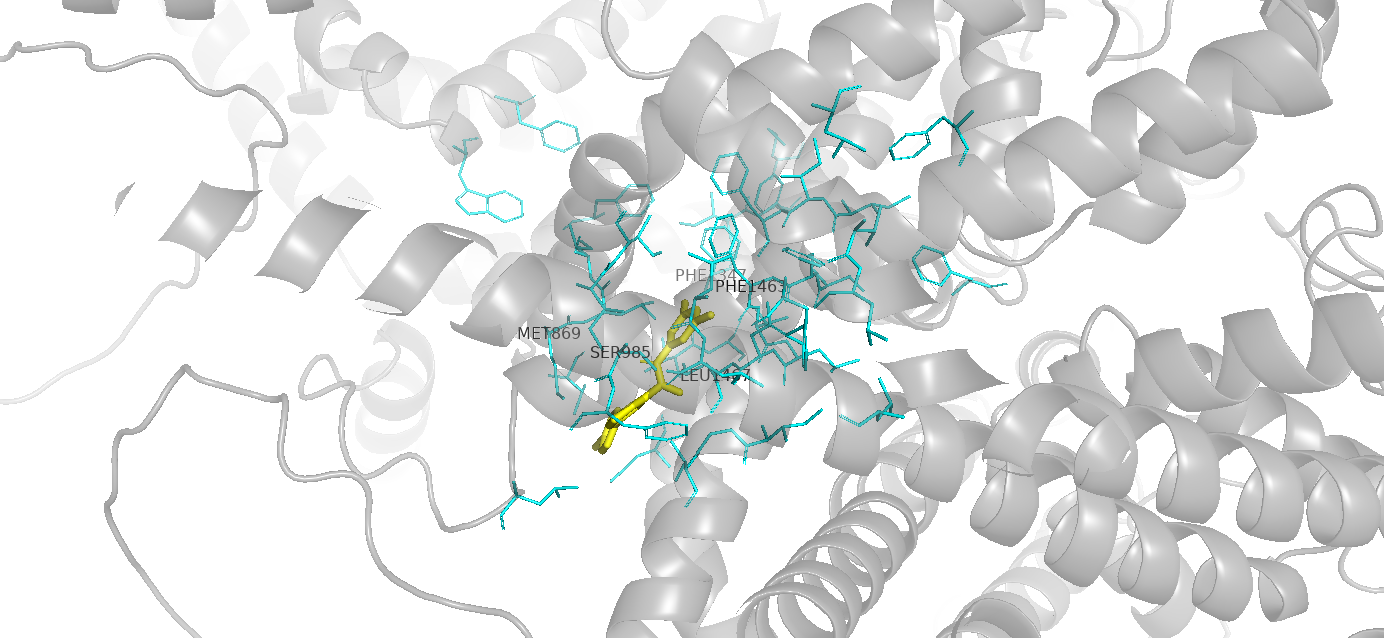

### Figure 2 - Q99250 / CHEMBL1277514

###### Representative PyMOL visualisation of CHEMBL1277514 docked within the predicted binding pocket of Q99250. The corresponding Vina affinity was −7.658 kcal/mol.

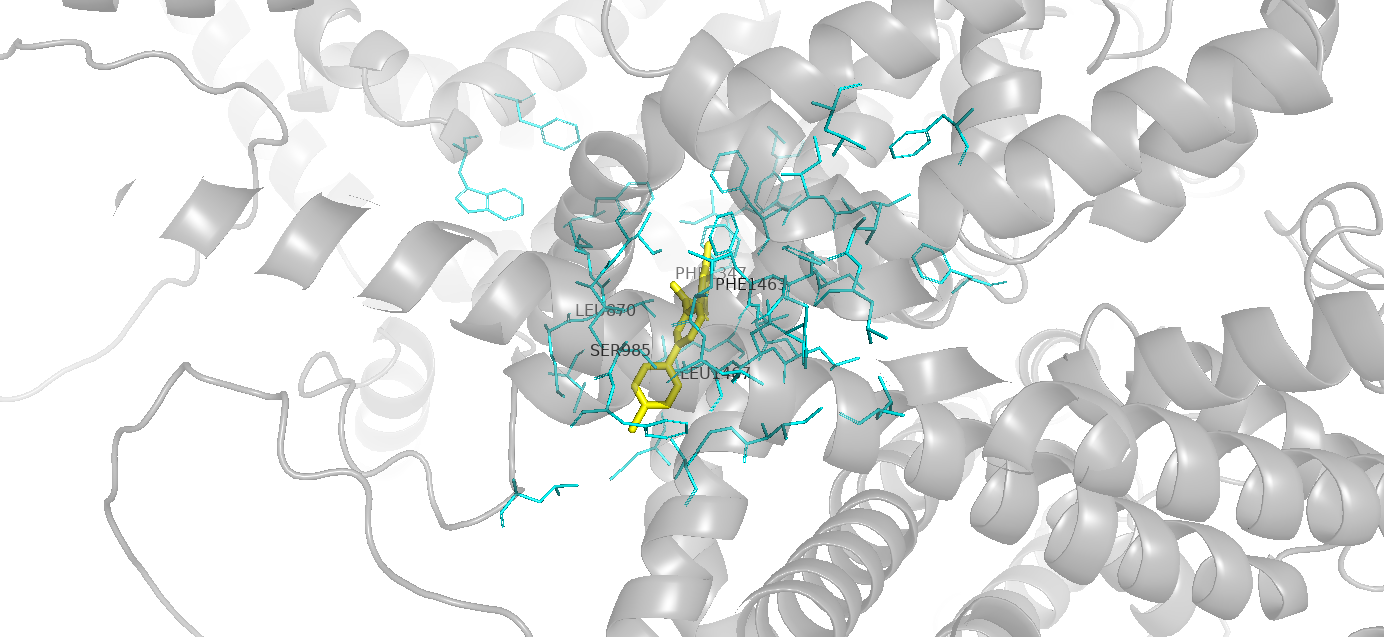

### Figure 3 - Q9Y5Y9 / CHEMBL1631097

###### Representative PyMOL visualisation of CHEMBL1631097 docked within the predicted binding pocket of Q9Y5Y9. The corresponding Vina affinity was −7.636 kcal/mol.

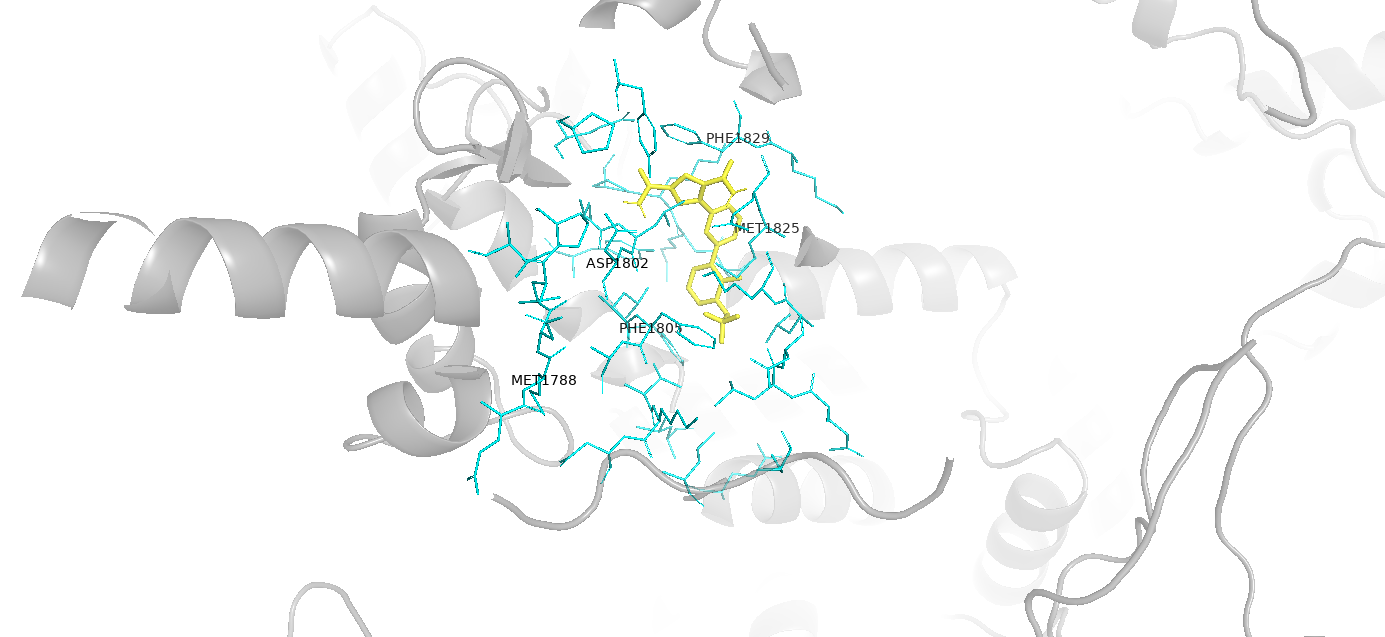


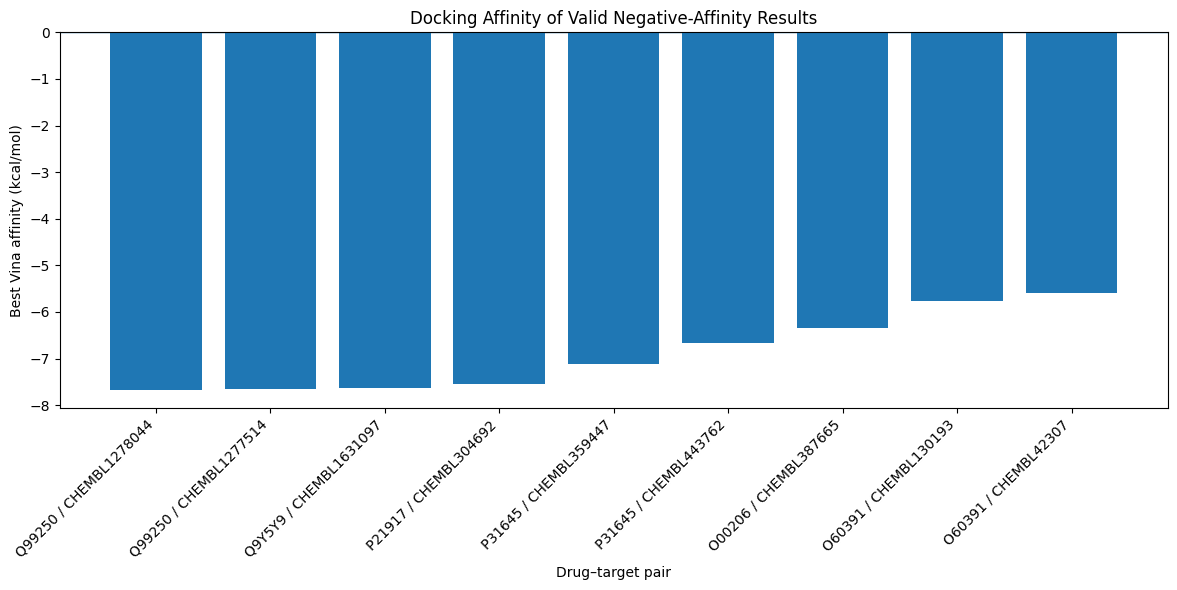

Docking score visualisation saved to:
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/docking/results/docking_affinity_valid_results.png
Results visualised: 9


In [42]:
# 31. Visualise Docking Scores

import matplotlib.pyplot as plt

# Use QC-filtered negative-affinity results only.
# The anomalous positive-affinity docking result is excluded
# from the main docking-score visualisation.

if "docking_qc_class" in docking_results.columns:

    docking_scores_for_visualisation = docking_results[
        docking_results["docking_qc_class"]
        == "valid_negative_affinity"
    ].copy()

else:

    docking_scores_for_visualisation = docking_results[
        docking_results["best_vina_affinity_kcal_mol"] < 0
    ].copy()


# Sort from most favourable to least favourable affinity.

docking_scores_for_visualisation = (
    docking_scores_for_visualisation
    .sort_values(
        "best_vina_affinity_kcal_mol",
        ascending=True
    )
    .reset_index(drop=True)
)


plt.figure(figsize=(12, 6))

labels = (
    docking_scores_for_visualisation["uniprot_id"]
    + " / "
    + docking_scores_for_visualisation["drug_chembl_id"]
)

plt.bar(
    labels,
    docking_scores_for_visualisation[
        "best_vina_affinity_kcal_mol"
    ]
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel(
    "Drug–target pair"
)

plt.ylabel(
    "Best Vina affinity (kcal/mol)"
)

plt.title(
    "Docking Affinity of Valid Negative-Affinity Results"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

docking_score_figure_path = os.path.join(
    DOCKING_RESULTS_PATH,
    "docking_affinity_valid_results.png"
)

plt.savefig(
    docking_score_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    f"Docking score visualisation saved to:\n"
    f"{docking_score_figure_path}"
)

print(
    f"Results visualised: "
    f"{len(docking_scores_for_visualisation)}"
)

In [43]:
# 32. Save Molecular Docking Results

docking_results_file = os.path.join(
    DOCKING_RESULTS_PATH,
    "molecular_docking_results.csv"
)

docking_results.to_csv(
    docking_results_file,
    index=False
)

print("Molecular docking results saved successfully.")
print("Saved file:", docking_results_file)

Molecular docking results saved successfully.
Saved file: /content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/docking/results/molecular_docking_results.csv


In [44]:
# 33. Save Final Docking Summary

# Save the final validated docking results for use in the dissertation.
# Only successfully completed docking runs with valid negative Vina
# affinities are included in the final summary.

FINAL_SUMMARY_PATH = os.path.join(
    DOCKING_RESULTS_PATH,
    "final_docking_validation_summary.csv"
)

# Make a copy so the original docking results remain unchanged
final_summary = docking_results.copy()

# Keep only successful docking runs
final_summary = final_summary[
    final_summary["status"].astype(str).str.lower().eq("success")
].copy()

# Convert docking affinity to numeric
final_summary["best_vina_affinity_kcal_mol"] = pd.to_numeric(
    final_summary["best_vina_affinity_kcal_mol"],
    errors="coerce"
)

# Classify docking results based on the Vina affinity
def classify_docking_affinity(value):
    if pd.isna(value):
        return "invalid"
    elif value < 0:
        return "valid_negative_affinity"
    else:
        return "anomalous_non_negative_affinity"


final_summary["docking_qc_class"] = (
    final_summary["best_vina_affinity_kcal_mol"]
    .apply(classify_docking_affinity)
)

# Keep valid negative-affinity results for the final validated summary
final_summary_valid = final_summary[
    final_summary["docking_qc_class"]
    == "valid_negative_affinity"
].copy()

# Sort by most favourable docking affinity
final_summary_valid = final_summary_valid.sort_values(
    by="best_vina_affinity_kcal_mol",
    ascending=True
).reset_index(drop=True)

# Save the validated summary
final_summary_valid.to_csv(
    FINAL_SUMMARY_PATH,
    index=False
)

print(
    f"Final docking validation summary saved successfully.\n"
    f"Saved file: {FINAL_SUMMARY_PATH}"
)

print(
    f"\nValid negative-affinity docking results: "
    f"{len(final_summary_valid)}"
)

# Display the final summary
display(final_summary_valid)

Final docking validation summary saved successfully.
Saved file: /content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/docking/results/final_docking_validation_summary.csv

Valid negative-affinity docking results: 9


,rank,uniprot_id,drug_chembl_id,prediction_probability,pocket_number,fpocket_score,druggability_score,center_x,center_y,center_z,best_vina_affinity_kcal_mol,exhaustiveness,number_of_poses,docked_pose_file,status,docking_qc_class
0,4,Q99250,CHEMBL1278044,1.000000,1,0.215,0.229,-19.263308,7.660769,-9.569385,-7.674,32,9,/content/drive/MyDrive/Dissertation/Depression...,success,valid_negative_affinity
1,3,Q99250,CHEMBL1277514,1.000000,1,0.215,0.229,-19.263308,7.660769,-9.569385,-7.658,32,9,/content/drive/MyDrive/Dissertation/Depression...,success,valid_negative_affinity
2,1,Q9Y5Y9,CHEMBL1631097,1.000000,1,0.085,0.337,-23.842837,21.764558,32.343326,-7.636,32,9,/content/drive/MyDrive/Dissertation/Depression...,success,valid_negative_affinity
3,2,P21917,CHEMBL304692,1.000000,1,0.135,0.003,-22.212952,-5.020095,15.092714,-7.546,32,9,/content/drive/MyDrive/Dissertation/Depression...,success,valid_negative_affinity
4,6,P31645,CHEMBL359447,1.000000,1,0.188,0.965,-0.491621,-1.624979,-2.291337,-7.112,32,9,/content/drive/MyDrive/Dissertation/Depression...,success,valid_negative_affinity
5,5,P31645,CHEMBL443762,1.000000,1,0.188,0.965,-0.491621,-1.624979,-2.291337,-6.655,32,9,/content/drive/MyDrive/Dissertation/Depression...,success,valid_negative_affinity
6,7,O00206,CHEMBL387665,1.000000,1,0.304,0.029,-27.681975,-5.910550,10.700900,-6.333,32,9,/content/drive/MyDrive/Dissertation/Depression...,success,valid_negative_affinity
7,10,O60391,CHEMBL130193,0.999995,1,0.099,0.003,43.375500,-2.024136,-53.679045,-5.775,32,9,/content/drive/MyDrive/Dissertation/Depression...,success,valid_negative_affinity
8,9,O60391,CHEMBL42307,0.999999,1,0.099,0.003,43.375500,-2.024136,-53.679045,-5.601,32,9,/content/drive/MyDrive/Dissertation/Depression...,success,valid_negative_affinity


## Summary of Findings

This notebook validated high-confidence novel drug-target predictions from the machine learning stage using molecular docking.

The predicted protein targets were matched with their available AlphaFold structures, and binding pockets were identified and ranked using fpocket. The selected drug structures were prepared for docking, while the protein structures were prepared as rigid PDBQT receptors for AutoDock Vina.

A total of 10 predicted drug-target pairs were successfully docked using AutoDock Vina. Nine docking runs produced negative affinity scores, while one result produced a positive affinity score of +20.237 kcal/mol. The positive result for Q8IWU9 and CHEMBL5172715 was retained in the raw results but classified separately as an anomalous docking result rather than being used in the main docking-score comparison.

Among the valid negative-affinity results, the most favourable predicted docking score was -7.674 kcal/mol for Q99250 with CHEMBL1278044. This was followed by Q99250 with CHEMBL1277514 at -7.658 kcal/mol and Q9Y5Y9 with CHEMBL1631097 at -7.636 kcal/mol.

The docking results were further checked using a quality-control step so that the anomalous positive-affinity result was separated from the main set of negative-affinity docking results.

Three representative protein-ligand docking results were selected for structural visualisation based on their docking affinity scores. The corresponding protein structures and docking poses were visually inspected using PyMOL to assess the position of the ligands within the predicted binding pockets. These visualisations provide additional structural information to support the docking analysis and will be used as representative figures in the dissertation.

The final docking results, quality-control classifications, and structural visualisation selection were saved in the project docking results directory for use in the subsequent dissertation analysis.

The docking scores should be considered as computational evidence of predicted binding rather than experimental confirmation. The final interpretation will therefore consider the machine learning prediction, binding-pocket properties, docking affinity, and structural visualisation together.